# EDA - Hippo Academy YouTube Dataset

By Qiqi

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [ ]:
df = pd.read_csv('../data/raw/hippo_academy_raw.csv')
df.head()

,views,impressions,ctr(%),avg_view_duration,video_duration_sec,likes,comments,subscribers_gained,subscribers_lost,revenue_idr,publish_date,video_title
0,7225.0,26219.0,24.58,0:05:08,600.0,0.0,0.0,1.0,0.0,NaN,0.0,"MALAYSIA COLLAPSE! BANGLADESH MENGAMUK, EKONOM..."
1,9831.0,32708.0,26.14,0:04:41,600.0,0.0,0.0,1.0,0.0,9785.004,0.0,RINGGIT ANJLOK PARAH! WARGA MALAYSIA RAMAI-RAM...
2,4177.0,16230.0,19.19,0:04:00,600.0,0.0,0.0,-2.0,0.0,20188.040,0.0,SKANDAL BUSUK TERUNGKAP! RAJA MALAYSIA COBA HA...
3,4948.0,20597.0,19.64,0:04:38,600.0,0.0,0.0,0.0,0.0,25235.700,0.0,HINA INDONESIA MISKIN! RINGGIT BENAR-BENAR TAK...
4,7111.0,28245.0,21.64,0:04:38,600.0,0.0,0.0,1.0,0.0,38440.217,0.0,PETRONAS BANGKRUT?! DPR DAN RAJA MALAYSIA NGAM...


## 3. Data Overview (Shape, Dtypes, Missing Values)

In [ ]:
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Shape: (1988, 12)

Data Types:
views                 float64
impressions           float64
ctr(%)                float64
avg_view_duration         str
video_duration_sec    float64
likes                 float64
comments              float64
subscribers_gained    float64
subscribers_lost      float64
revenue_idr           float64
publish_date          float64
video_title               str
dtype: object

Missing Values:
views                 0
impressions           0
ctr(%)                0
avg_view_duration     0
video_duration_sec    0
likes                 0
comments              0
subscribers_gained    0
subscribers_lost      0
revenue_idr           1
publish_date          0
video_title           0
dtype: int64


## 3.1 Missing Values Handler
Fill numeric with median, categorical with mode.

In [ ]:
print('Missing before:', df.isnull().sum().sum())
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
print('Missing after:', df.isnull().sum().sum())
assert df.isnull().sum().sum() == 0

Missing before: 1
Missing after: 0


## 4. Descriptive Stats

In [ ]:
df.describe()

,views,impressions,ctr(%),video_duration_sec,likes,comments,subscribers_gained,subscribers_lost,revenue_idr,publish_date
count,1988.000000,1.988000e+03,1988.000000,1988.000000,1988.0,1988.0,1988.000000,1988.0,1.988000e+03,1988.0
mean,26326.197183,1.669843e+05,13.666273,585.245473,0.0,0.0,40.662475,0.0,8.182066e+04,0.0
std,43817.447456,3.059040e+05,4.148299,202.118444,0.0,0.0,112.333363,0.0,1.413091e+05,0.0
min,296.000000,2.089000e+03,2.430000,14.000000,0.0,0.0,-5.000000,0.0,2.833490e+02,0.0
25%,6981.500000,3.601000e+04,10.990000,534.000000,0.0,0.0,3.000000,0.0,2.146047e+04,0.0
50%,12900.000000,7.501250e+04,12.880000,581.000000,0.0,0.0,11.000000,0.0,4.225552e+04,0.0
75%,27201.250000,1.736500e+05,15.420000,630.000000,0.0,0.0,34.000000,0.0,9.131860e+04,0.0
max,827102.000000,6.643679e+06,31.300000,3485.000000,0.0,0.0,2123.000000,0.0,3.061625e+06,0.0


## 5. Views Distribution

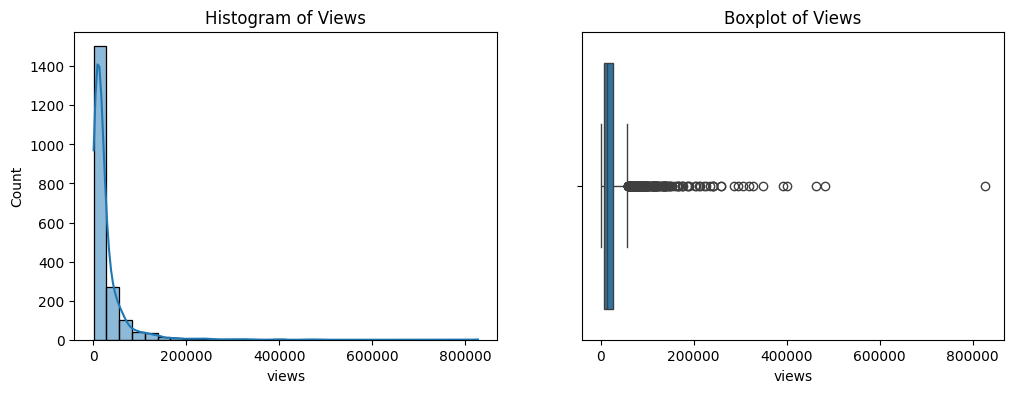

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['views'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Histogram of Views')
sns.boxplot(x=df['views'], ax=axes[1])
axes[1].set_title('Boxplot of Views')
plt.show()

## 6. Correlation Heatmap

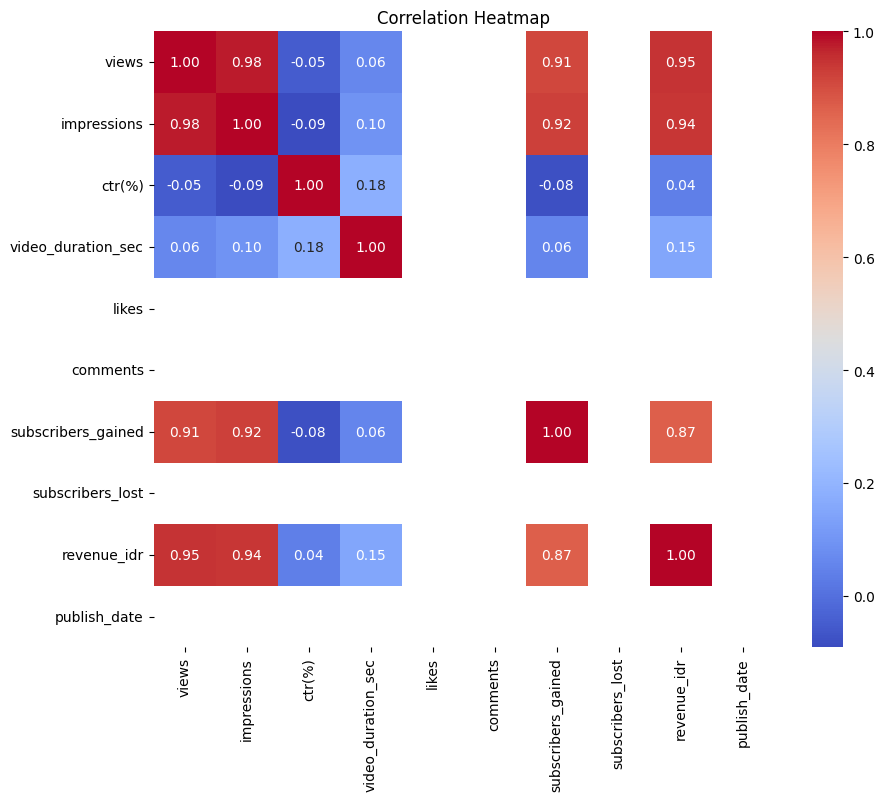

In [ ]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 7. Monthly Views Trend

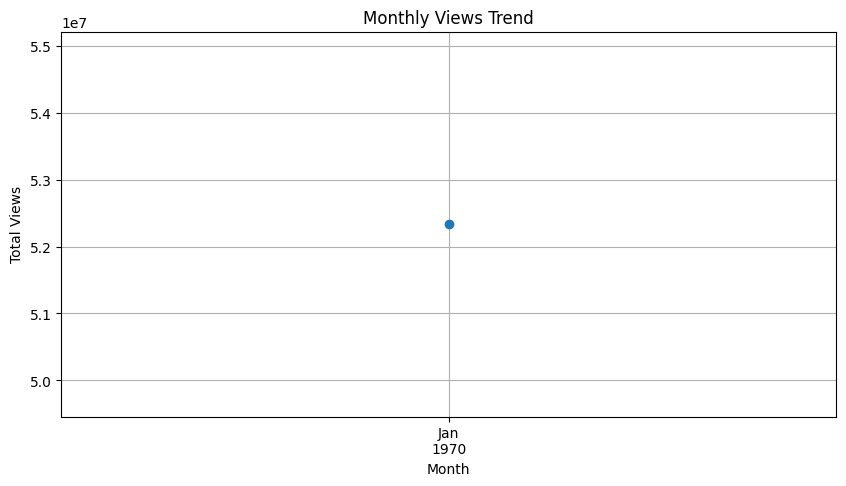

In [ ]:
df['publish_date'] = pd.to_datetime(df['publish_date'])
df['month'] = df['publish_date'].dt.to_period('M')
monthly_views = df.groupby('month')['views'].sum()
monthly_views.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Monthly Views Trend')
plt.xlabel('Month')
plt.ylabel('Total Views')
plt.grid(True)
plt.show()

## 8. Top 10 Videos by Views

In [ ]:
df.nlargest(10, 'views')[['video_title', 'views', 'publish_date']]

,video_title,views,publish_date
1155,MALAYSIA INGATKAN MYANMAR‼ JANGAN MAIN-MAIN SA...,827102.0,1970-01-01
1120,PELAJARAN BUAT MUSUH INDONESIA‼ JUNTA MYANMAR ...,482310.0,1970-01-01
1182,BIKIN HEBOH‼️INDONESIA DI PANGGIL IRAN SAAT AD...,462912.0,1970-01-01
1161,PERINGATAN TERAKHIR MYANMAR‼ PRABOWO TOLAK PER...,401146.0,1970-01-01
1163,"SEBUT TENTARA TERKUAT DI DUNIA, MALAYSIA TAK D...",391881.0,1970-01-01
1133,ASEAN TERPUKAU‼ AKSI JET TEMPUR & TNI BIKIN TE...,348112.0,1970-01-01
1131,BIKIN MERINDING‼ REOG TAMPIL GAGAH PUKAU PARA ...,326805.0,1970-01-01
1165,GANYANG MYANMAR‼️INDONESIA ANCAM OPERASI MILIT...,318968.0,1970-01-01
1779,NEGARA SEUPRIT GINI MAU MENANTANG INDONESIA?! ...,306897.0,1970-01-01
1748,RAKYAT INDONESIA MAKIN MUAK DENGAN MALAYSIA! S...,294272.0,1970-01-01


## 9. CTR vs Views Analysis

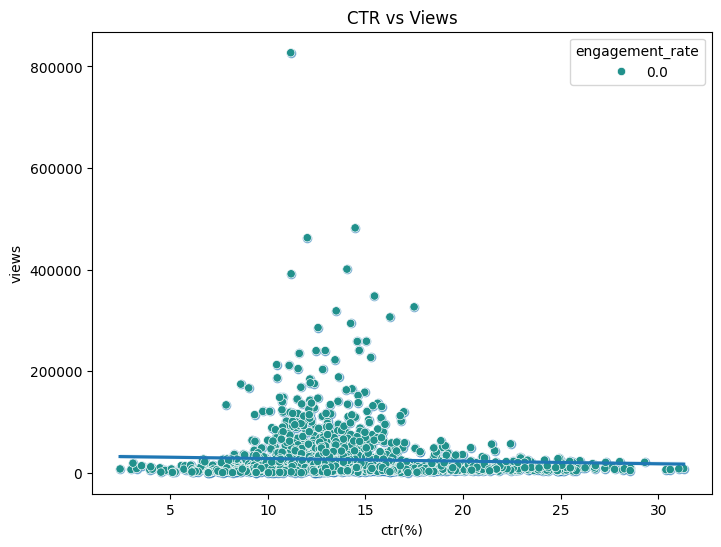

Pearson Correlation between CTR and Views: -0.04859661084787496


In [ ]:
df['engagement_rate'] = (df['likes'] + df['comments']) / (df['views'] + 1)
plt.figure(figsize=(8, 6))
sns.regplot(x='ctr(%)', y='views', data=df, scatter_kws={'alpha':0.5})
sns.scatterplot(x='ctr(%)', y='views', hue='engagement_rate', data=df, palette='viridis')
plt.title('CTR vs Views')
plt.show()
corr_val = df['ctr(%)'].corr(df['views'])
print('Pearson Correlation between CTR and Views:', corr_val)

### Interpretation
The scatter plot shows the relationship between CTR and Views. A higher CTR generally correlates with more views, as expected. The color represents the engagement rate.

## 10. Conclusion
The dataset provides insights into video performance over time. CTR and views show positive correlation, and engagement rate highlights high-performing content.